In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter("ignore")
import omicverse as ov
ov.plot_set()


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.11, Tutorials: https://omicverse.readthedocs.io/
Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [2]:
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.3 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [3]:
adata = ov.read('/home/lugli/spuccio/Projects/SP039/GBmap/Ravi2022_Part3.h5ad')

In [4]:
adata.obs['scsa_celltype_panglaodb'].value_counts()

scsa_celltype_panglaodb
Microglia                 14553
Macrophages                8045
T Cells                    7631
Oligodendrocytes           3958
Osteoclasts                3590
Monocytes                   932
NK Cells                    802
Pluripotent Stem Cells      564
Interneurons                278
B Cells                      83
Name: count, dtype: int64

In [5]:
optim_palette=ov.pl.optim_palette(adata,basis='X_umap',colors='scsa_celltype_panglaodb')

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 50.76
|-----> Optimizing color mapping...


In [6]:
adata.var['start_position'] = adata.var['start_position'].astype(int)
adata.var['end_position'] = adata.var['end_position'].astype(int)

In [7]:
adata.var.columns

Index(['mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances',
       'residual_variances', 'ensembl_gene_id', 'start_position',
       'end_position', 'chromosome_name'],
      dtype='object')

In [8]:
adata.var.columns = ['mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances',
       'residual_variances', 'ensembl_gene_id', 'start',
       'end', 'chromosome']

In [9]:
adata.var['chromosome'] = "chr"+adata.var['chromosome'].astype(str)

In [10]:
list(adata.obs['annotation_level_2'].unique())  

['Myeloid',
 'Lymphoid',
 'Differentiated-like',
 'Stem-like',
 'Glial-Neuronal',
 'Vascular']

In [11]:
adata.obs['annotation_level_2'].value_counts()

annotation_level_2
Myeloid                28527
Lymphoid                7586
Glial-Neuronal          4105
Stem-like                135
Differentiated-like       81
Vascular                   2
Name: count, dtype: int64

In [12]:
cnv.tl.infercnv(
    adata,
    reference_key="annotation_level_2",
    reference_cat=[
    "Myeloid",
    "Lymphoid"],
    window_size=250,
)

  0%|          | 0/9 [00:00<?, ?it/s]

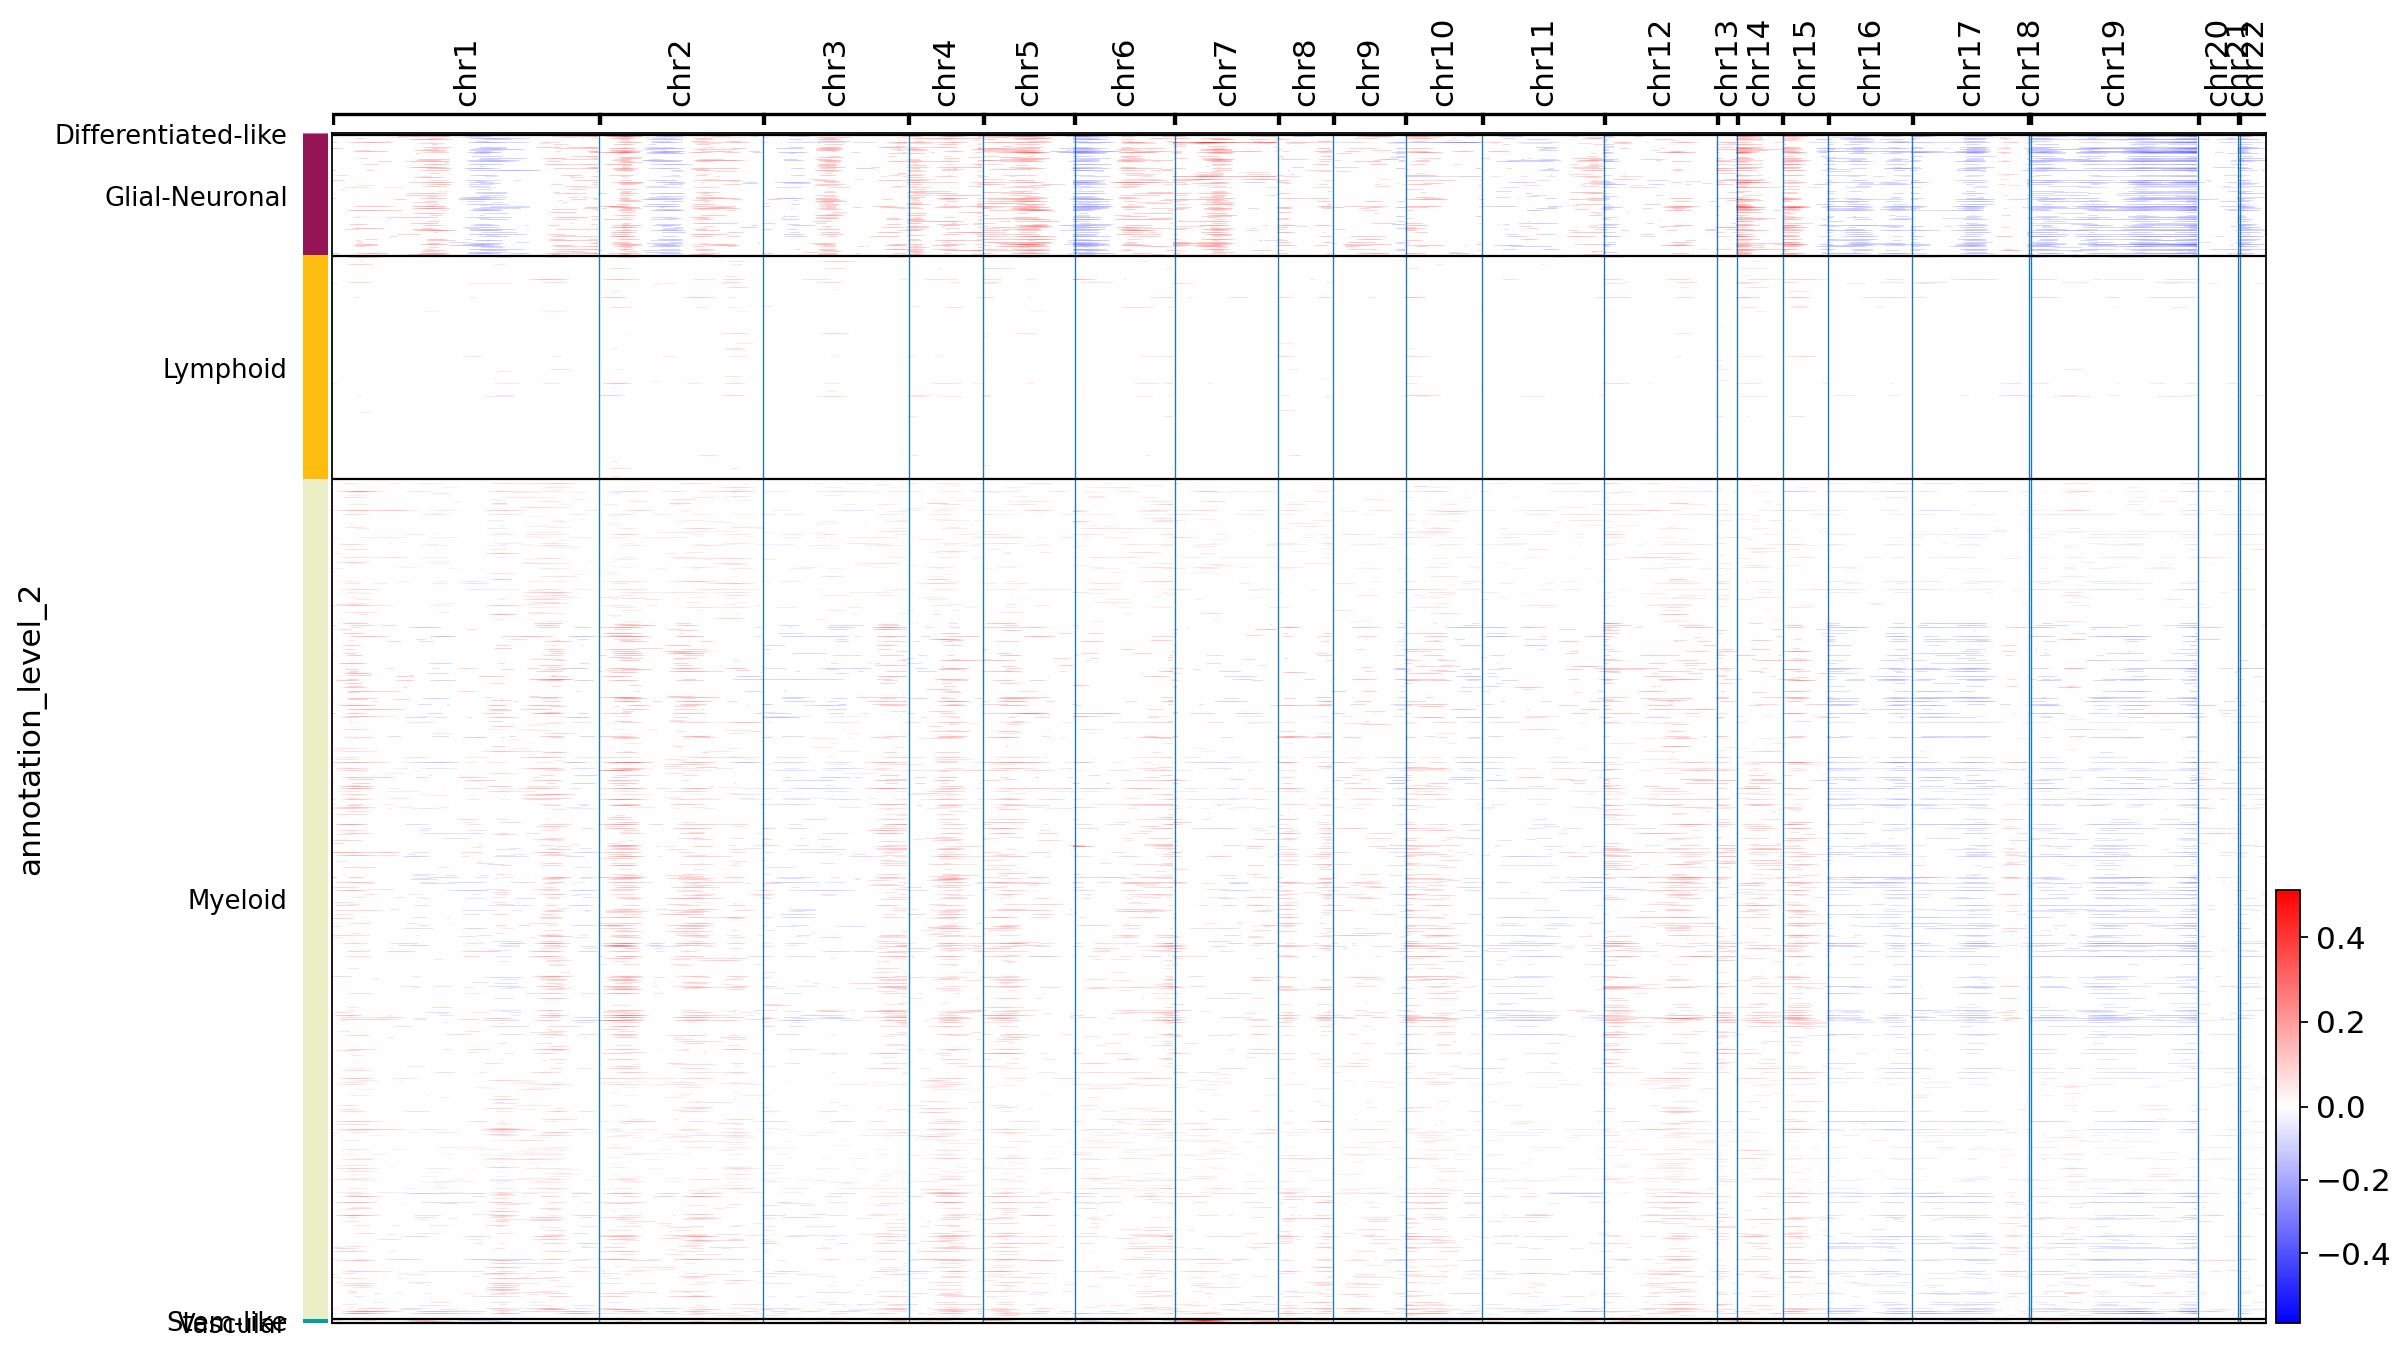

In [13]:
cnv.pl.chromosome_heatmap(adata, groupby="annotation_level_2")

In [14]:
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:25)


In [15]:
ov.pp.leiden(adata,resolution=0.4)

running Leiden clustering
    finished: found 14 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:33)


In [16]:
adata.uns['cnv_neighbors'] = adata.uns['neighbors']

In [17]:
cnv.tl.leiden(adata)

running Leiden clustering
    finished: found 21 clusters and added
    'cnv_leiden', the cluster labels (adata.obs, categorical) (0:00:40)


In [18]:
del adata.uns['leiden_colors']

In [19]:
adata

AnnData object with n_obs × n_vars = 40436 × 16565
    obs: 'donor_id', 'Author', 'stage', 'assay', 'tissue', 'Cells', 'Method', 'n_genes', 'nUMIs', 'annotation_level_1', 'annotation_level_2', 'annotation_level_3', 'scsa_celltype_cellmarker', 'scsa_celltype_panglaodb', 'cell_type', 'S_score', 'G2M_score', 'phase', 'leiden', 'cnv_leiden'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'ensembl_gene_id', 'start', 'end', 'chromosome'
    uns: 'X_approximate_distribution', 'annotation_level_1_colors', 'annotation_level_2_colors', 'annotation_level_3_colors', 'batch_condition', 'default_embedding', 'donor_id_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'schema_version', 'scsa_celltype_cellmarker_colors', 'scsa_celltype_panglaodb_colors', 'title', 'umap', 'cnv', 'cnv_neighbors', 'cnv_leiden'
    obsm: 'X_harmony', 'X_pca', 'X_umap', 'scaled|

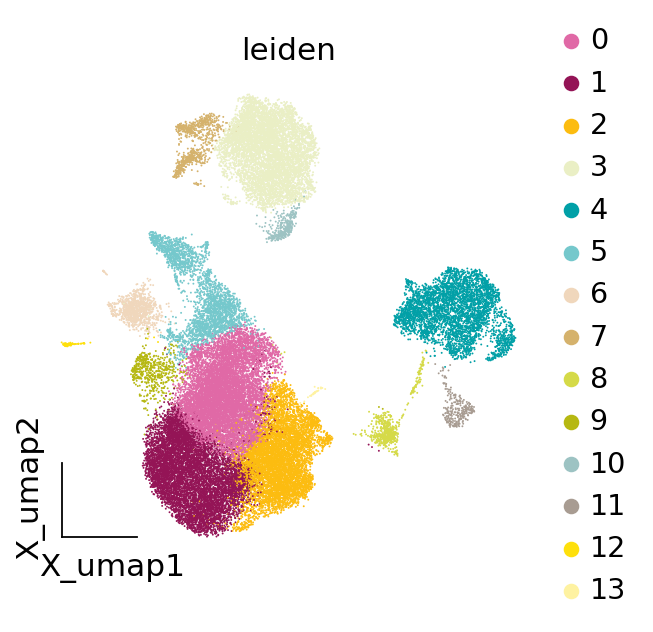

In [20]:
ov.utils.embedding(adata,
                   basis='X_umap',
                   color=['leiden'],
                   frameon='small',
                   legend_fontoutline=2,palette=ov.utils.palette()[14:],wspace=0.5
                  )

In [21]:
optim_palette2=ov.pl.optim_palette(adata,basis='X_umap',colors='leiden')

|-----> Calculating cluster distance graph...
|-----------> Calculating cell neighborhood...
|-----------> Filtering out neighborhood outliers...
|-----------> Calculating cluster interlacement score...
|-----------> Constructing cluster interlacement graph...
|-----> Calculating color distance graph...
|-----------> Calculating color perceptual distance...
|-----------> Constructing color distance graph...
|-----------> Difference of the most similar pair in the palette is 50.76
|-----> Optimizing color mapping...


In [22]:
sc.tl.dendrogram(adata, groupby='leiden')

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden']`


categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


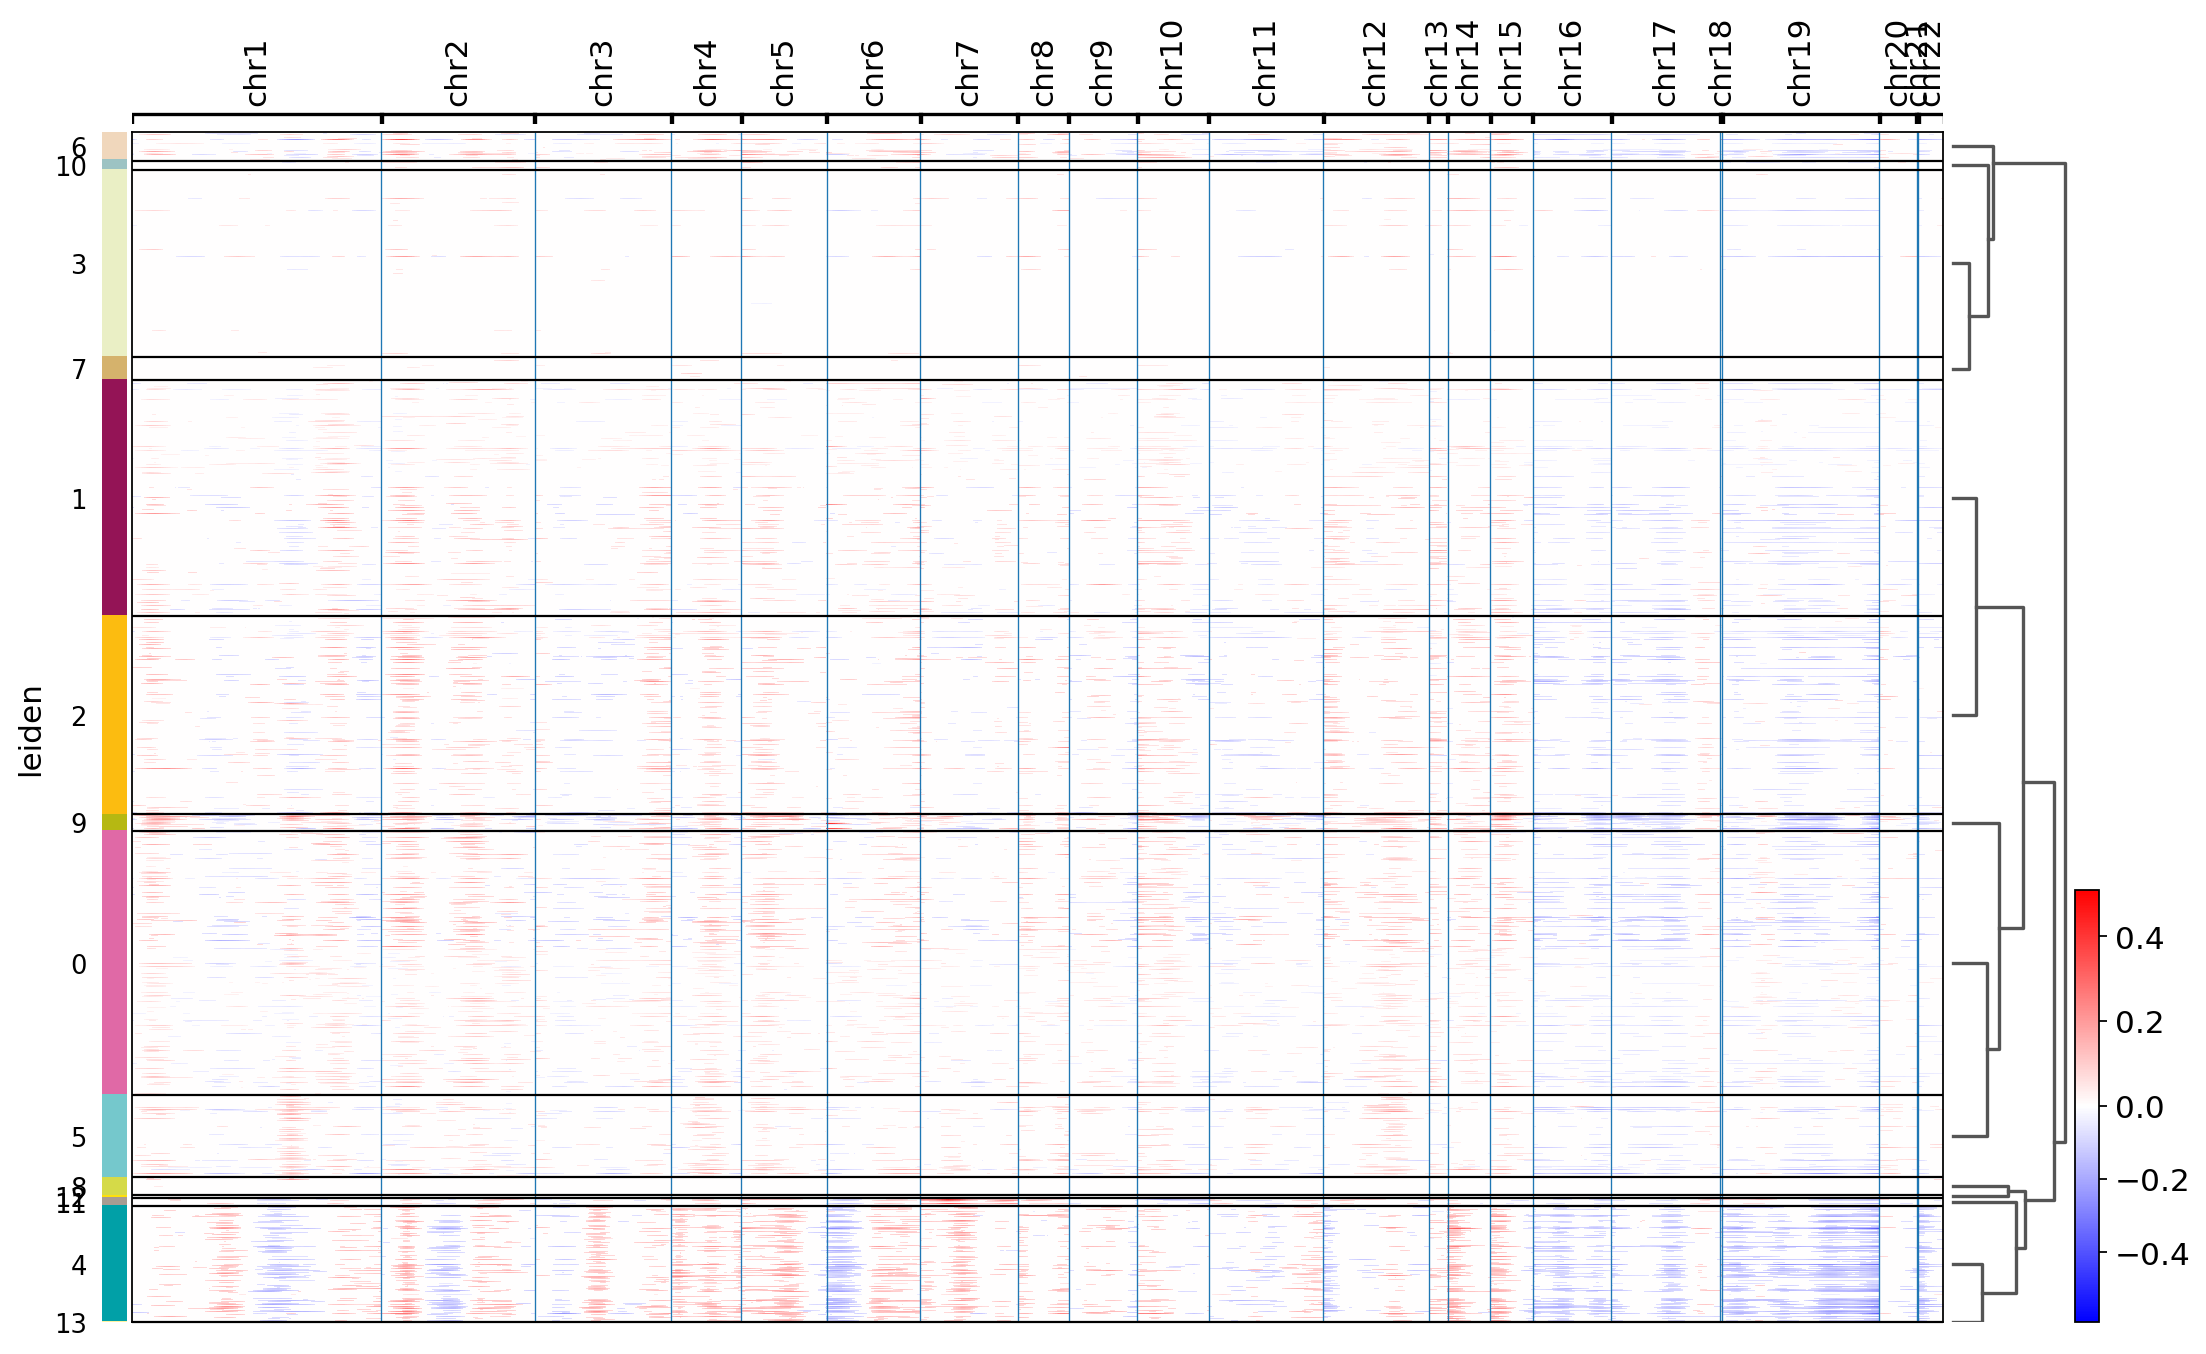

In [23]:
cnv.pl.chromosome_heatmap(adata, groupby="leiden", dendrogram=True)

In [24]:
cnv.tl.cnv_score(adata)

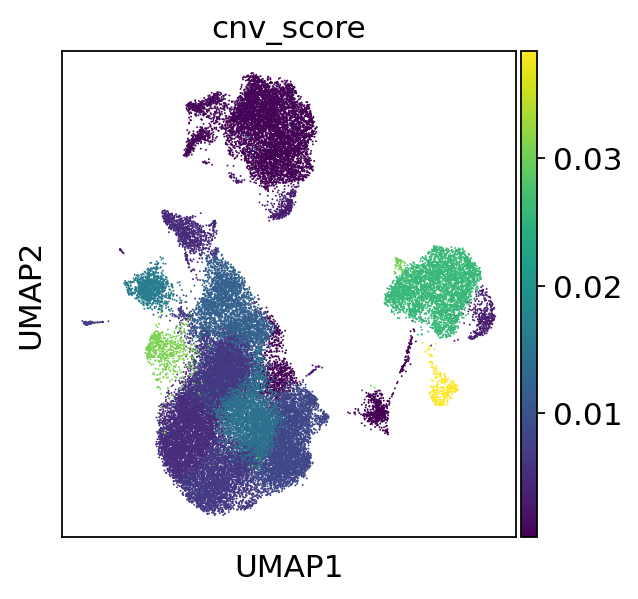

In [25]:
sc.pl.umap(adata, color="cnv_score")

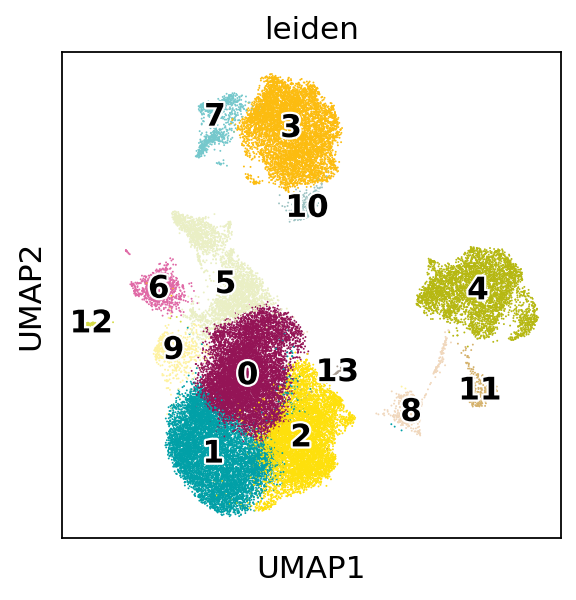

In [26]:
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",s=3,
    legend_fontoutline=2,palette=optim_palette2
)

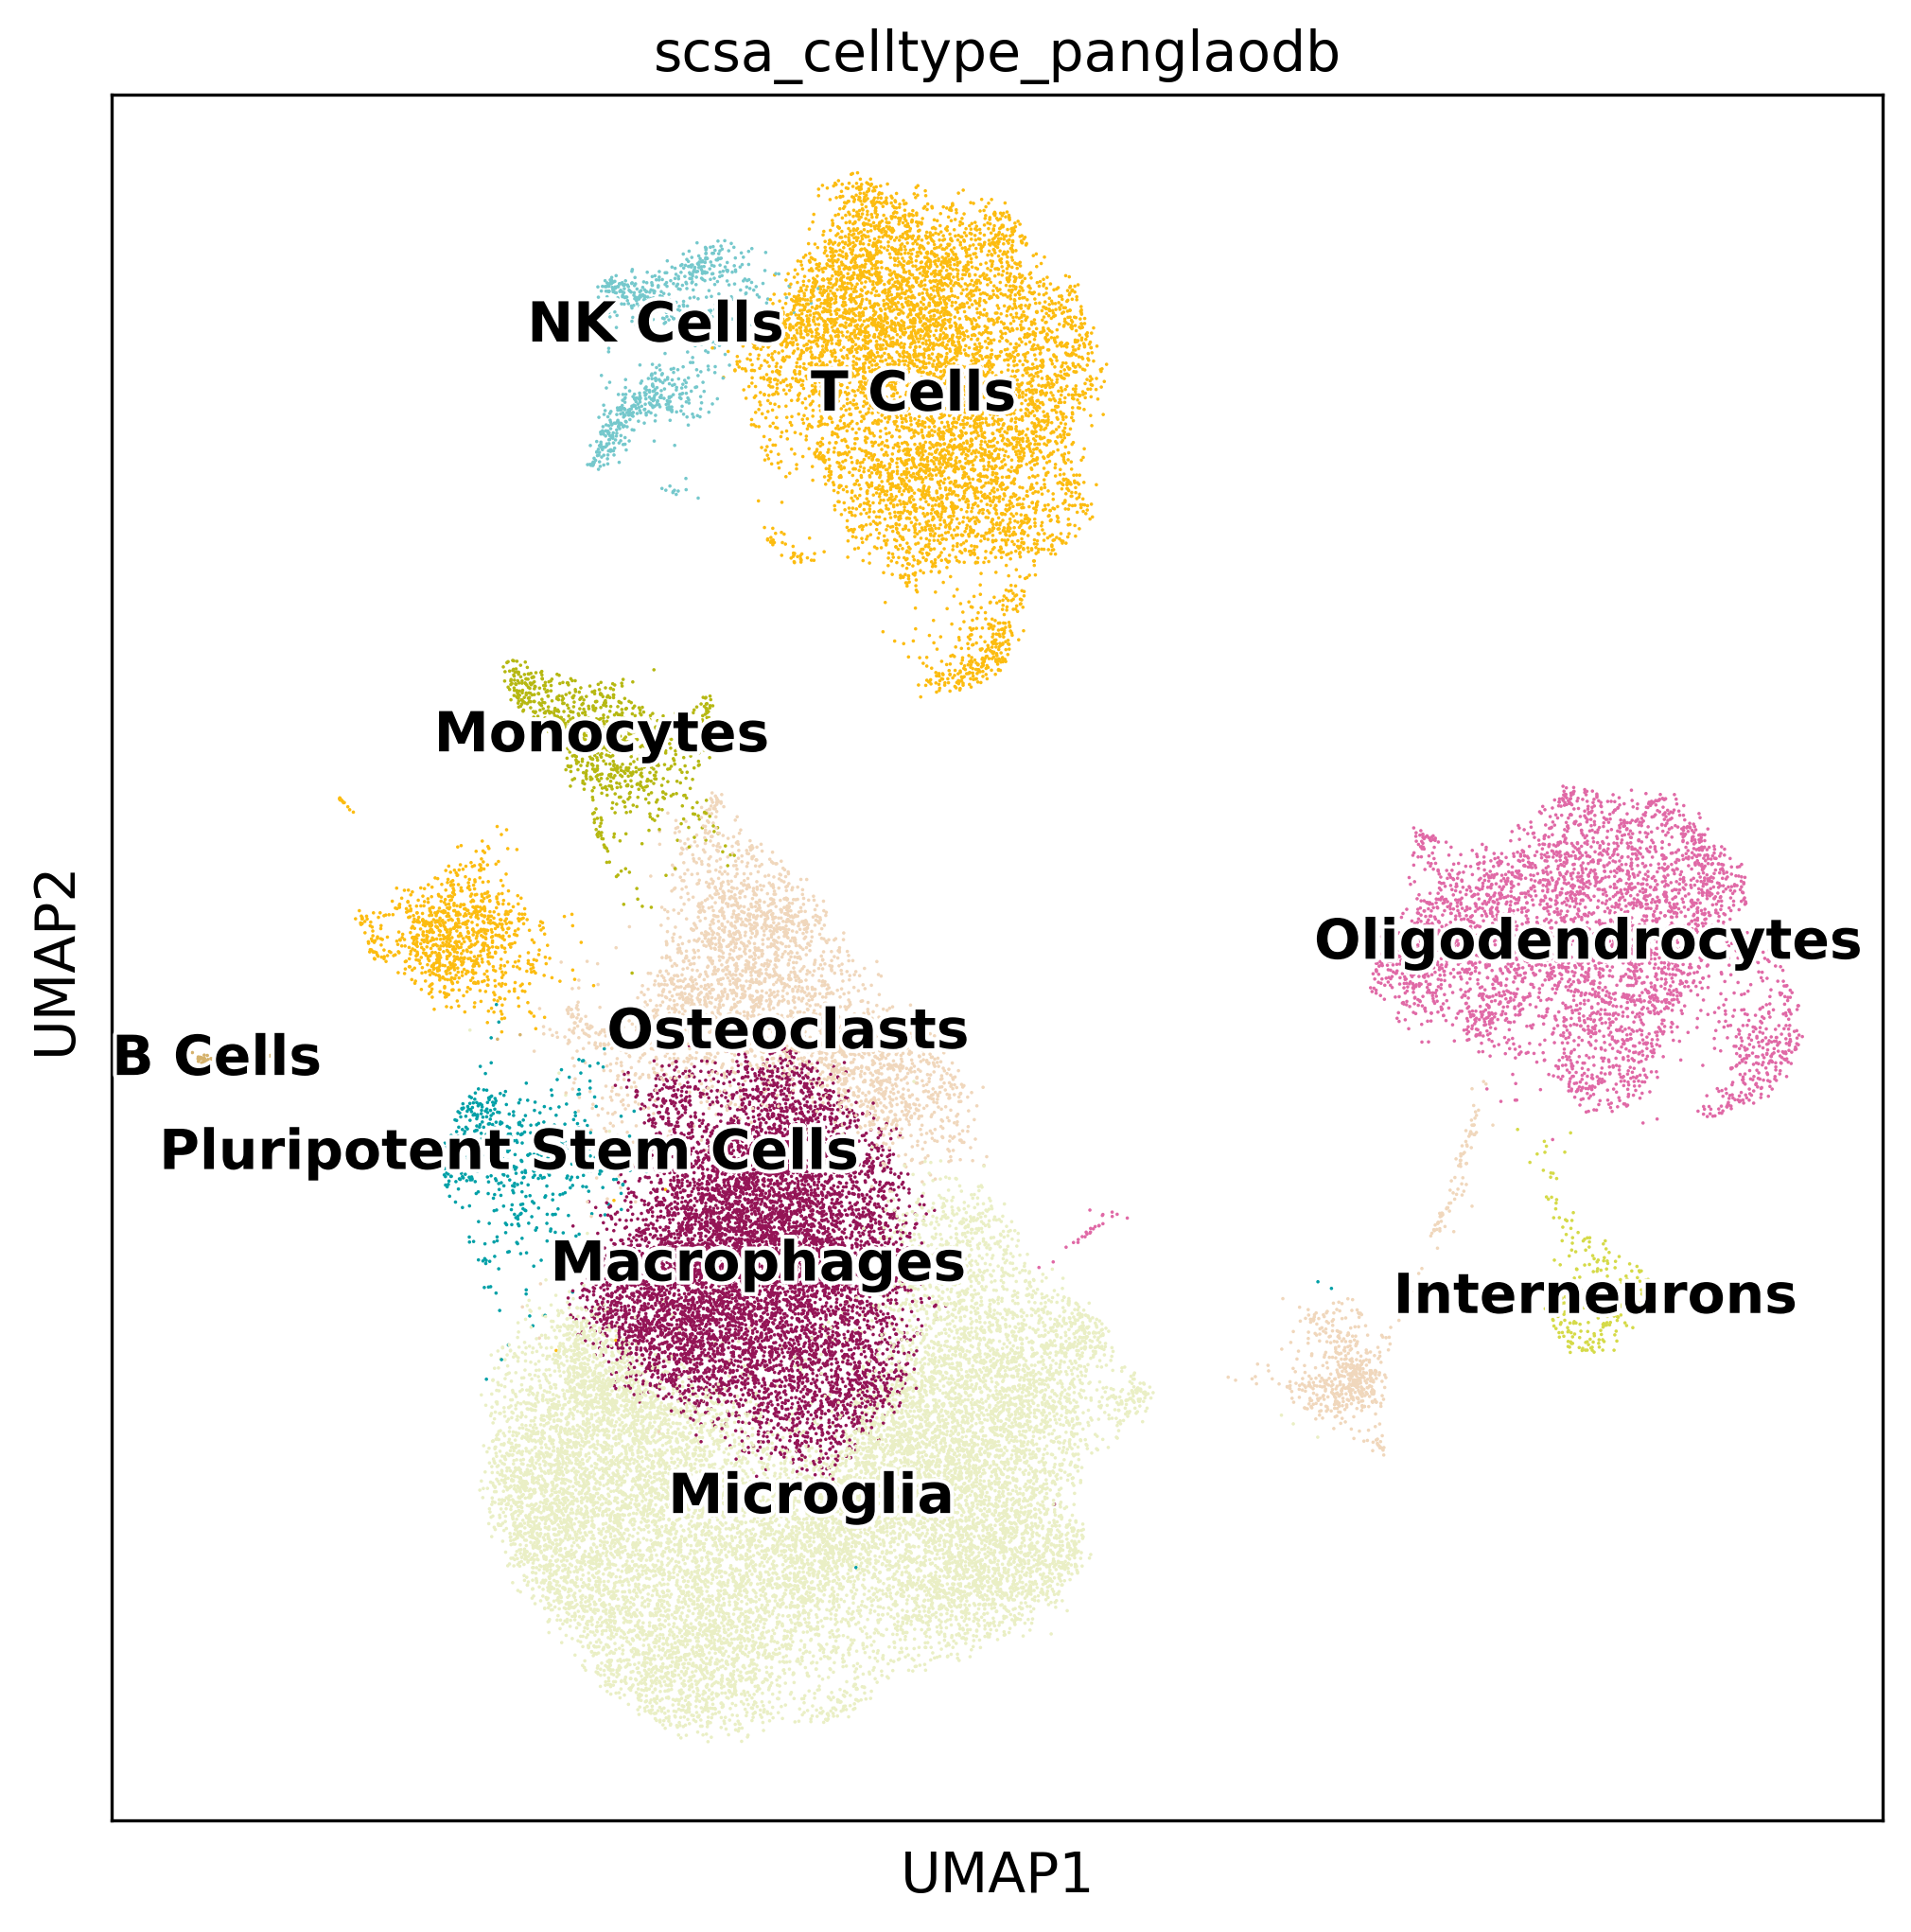

In [27]:
with plt.rc_context({"figure.figsize": (8, 8), "figure.dpi": (150)}):
    sc.pl.umap(
    adata,
    color="scsa_celltype_panglaodb",
    legend_loc="on data",palette=optim_palette,
    legend_fontoutline=2)



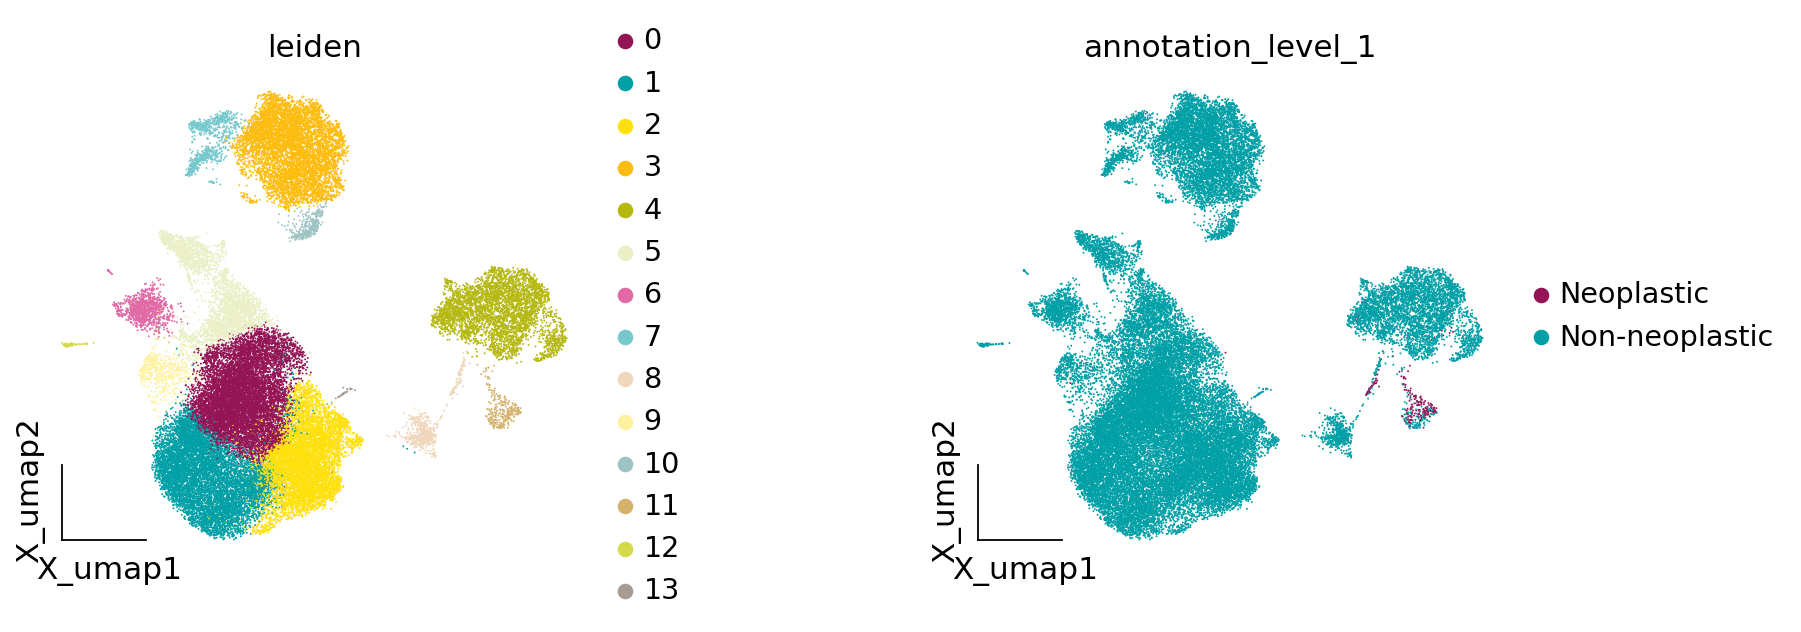

In [28]:
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden','annotation_level_1'],palette=optim_palette2,s=3,
                frameon='small',wspace=0.5)

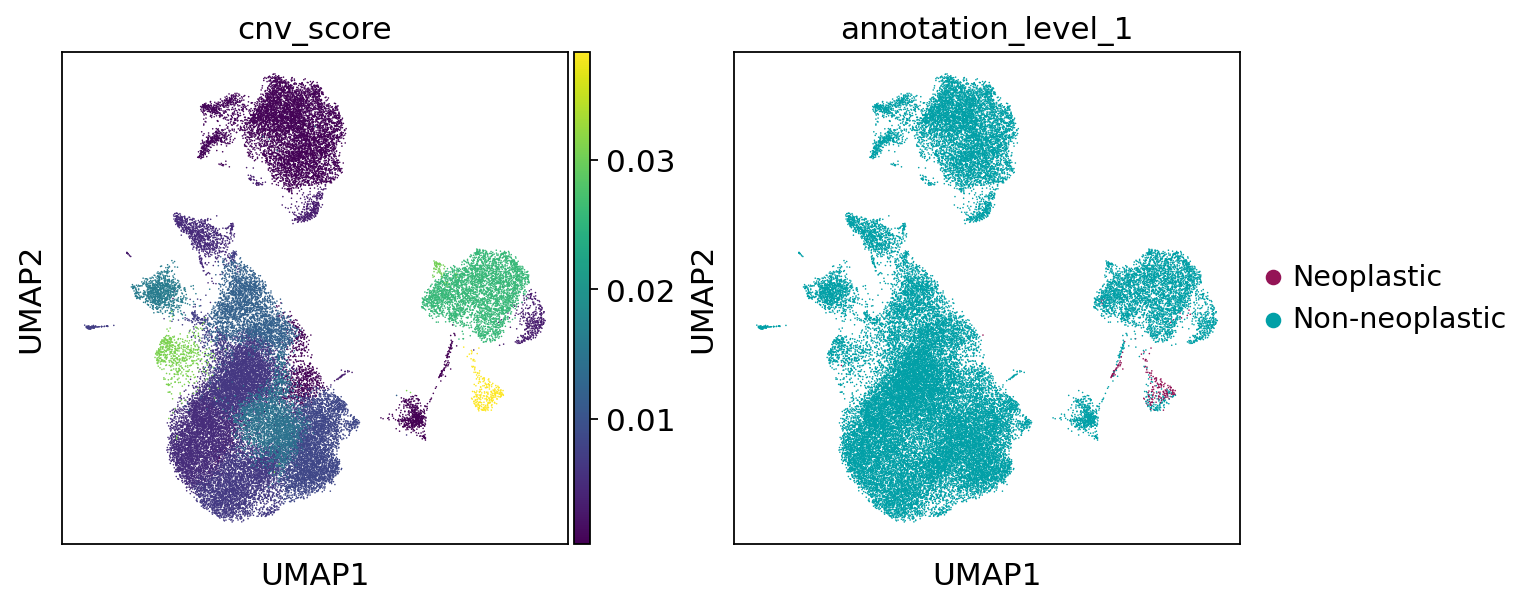

In [29]:
sc.pl.umap(adata, color=["cnv_score","annotation_level_1"],s=2)

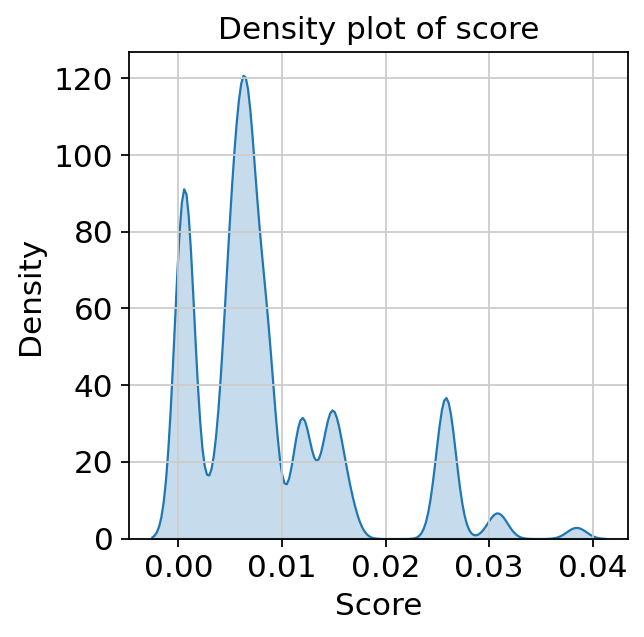

In [30]:
import seaborn as sns
sns.kdeplot(adata.obs["cnv_score"], fill=True)
plt.xlabel("Score")
#plt.axvline(x=filt_var, color='red', linestyle='--', linewidth=2)
plt.title("Density plot of score")
plt.show()

In [31]:
filt_var = 0.028

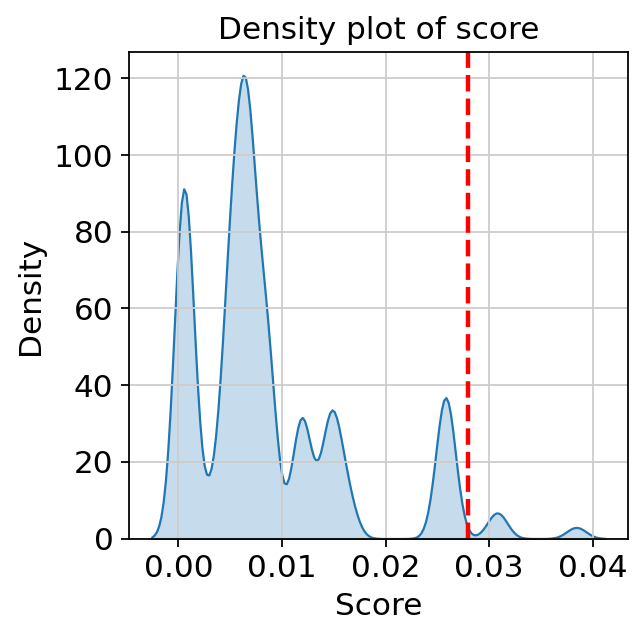

In [32]:
import seaborn as sns
sns.kdeplot(adata.obs["cnv_score"], fill=True)
plt.xlabel("Score")
plt.axvline(x=filt_var, color='red', linestyle='--', linewidth=2)
plt.title("Density plot of score")
plt.show()

In [33]:
immune_cells = [
    "Myeloid",
    "Lymphoid"
]

# Filter out cells that are in immune_cells and have cnv_score > 0.04
filtered_adata = adata[~(
    (adata.obs["annotation_level_2"].isin(immune_cells)) &
    (adata.obs["cnv_score"] > filt_var)
)]

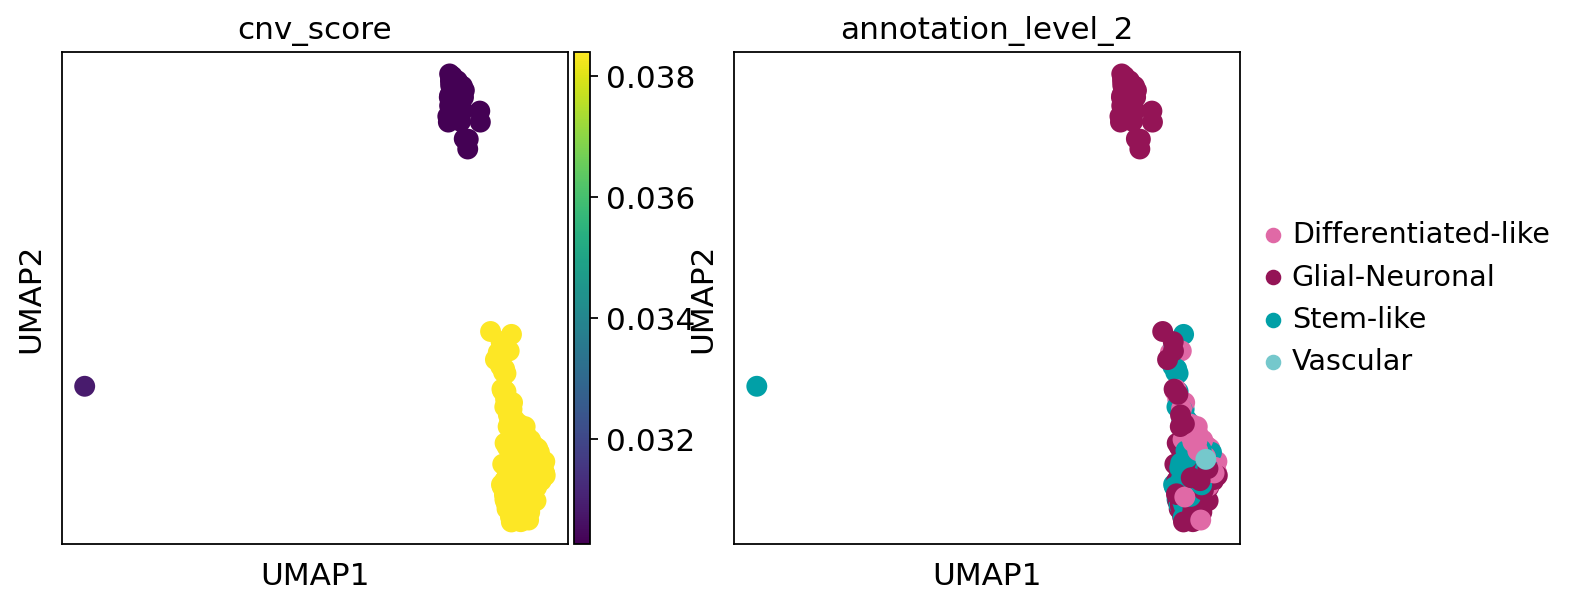

In [34]:
sc.pl.umap(filtered_adata[filtered_adata.obs["cnv_score"] > filt_var,:], color=["cnv_score","annotation_level_2"])

In [35]:
filtered_adata.obs["cnv_status"] = "normal"
filtered_adata.obs.loc[filtered_adata.obs["cnv_score"]> filt_var, "cnv_status"] = (
    "tumor"
)

In [36]:
filtered_adata2 = adata[(
    (adata.obs["annotation_level_2"].isin(immune_cells)) &
    (adata.obs["cnv_score"] > filt_var)
)]

In [37]:
filtered_adata2.obs["cnv_status"] = "normal"

In [38]:
adata = sc.concat([filtered_adata,filtered_adata2])

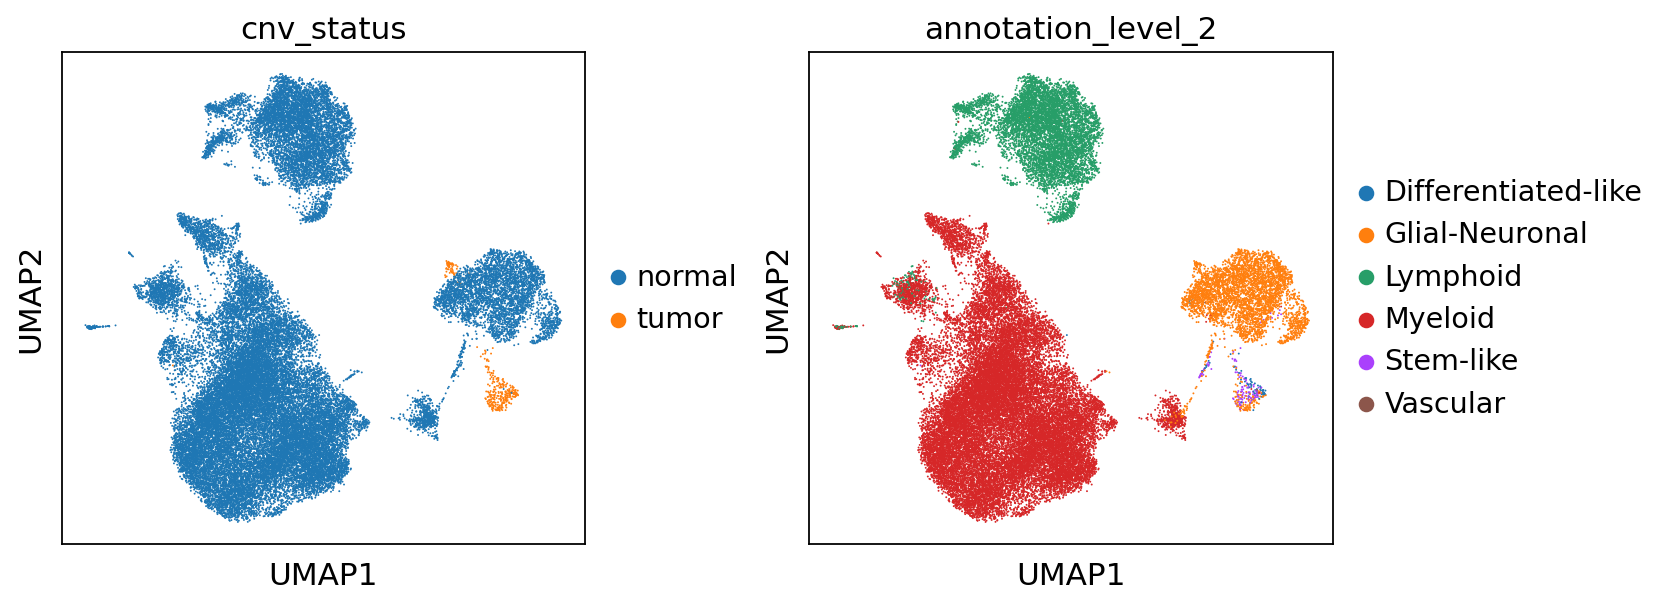

In [39]:
sc.pl.umap(adata, color=["cnv_status","annotation_level_2"],wspace=0.3)

In [40]:
#filtered_adata.obs["annotation_level_1"] = filtered_adata.obs["cnv_status"]

In [41]:
adata.write("/home/lugli/spuccio/Projects/SP039/GBmap/Ravi2022_Part4.h5ad")